In [1]:
# Importamos librerías
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.animation as animation
from IPython.display import HTML

### Configuración inicial

In [2]:
# Configuración de la grilla
# Definición de la grilla
#W = L = 10.0 # Dominio 
W = 20
L = 10
DX = DY = 0.1 # Espaciado de la grilla

# Pixeles de la grilla por dimensión
NX = int(W / DX)
NY = int(L / DY)

# Distribución gaussiana f0
SIGMA = 0.5

### Definición de f(t=0)

In [3]:
# Creación de la grilla 2D
x = np.arange(NX) * DX
y = np.arange(NY) * DY

'''
By default, NumPy's np.meshgrid uses Cartesian ('xy') indexing, which means the first input vector corresponds to the columns 
(x-axis) and the second input vector corresponds to the rows (y-axis)
'''
x, y = np.meshgrid(x, y)

# Definición del centro gaussiano
cx, cy = 5.0, 5.0

# Distancia al centro
rx = x - cx
ry = y - cy
r2 = rx**2 + ry**2

# Configuración inicial como distribución gaussiana centrada
u0 = np.exp(-r2 / SIGMA**2)

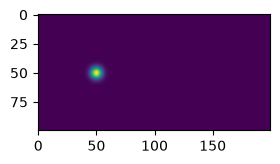

In [ ]:
# Visualización f(t=0)

fig, ax = plt.subplots(figsize=(3, 3))
im1 = ax.imshow(u0, cmap='viridis')

### Implementación modelo

In [5]:
# Función para crear un campo de velocidades
def gen_vels_field(N_x, N_y, V):
    return np.ones((N_y, N_x), dtype=int)*V

'''
In a NumPy 2D array, the indexing order is [row, column]. When comparing this to Cartesian coordinates 
\((x, y)\), rows correspond to \(y\) and columns correspond to \(x\)
'''

# Derivada primera de f en x
def first_der_X(matrix, n_x, n_y, h_x):

    matrix_copy = matrix.copy()

    for r in range(1, n_y - 1):  # Y direction / rows
        for c in range(1, n_x - 1):  # X direction / columns

            first_der_comp = (
                matrix[r, c + 1] - matrix[r, c - 1]
            ) / (2 * h_x)

            matrix_copy[r, c] = first_der_comp

    return matrix_copy

# Derivada primera de f en y
def first_der_Y(matrix, n_x, n_y, h_y):

    matrix_copy = matrix.copy()

    for r in range(1, n_y - 1):  # Y direction / rows
        for c in range(1, n_x - 1):  # X direction / columns

            first_der_comp = (
                matrix[r + 1, c] - matrix[r - 1, c]
            ) / (2 * h_y)

            matrix_copy[r, c] = first_der_comp

    return matrix_copy

# Derivada segunda de f en x
def secd_der_X(matrix, n_x, n_y, h_x):

    matrix_copy = matrix.copy()

    for r in range(1, n_y - 1):  # Y direction / rows
        for c in range(1, n_x - 1):  # X direction / columns

            secd_der_comp = (
                matrix[r, c + 1]
                - 2 * matrix[r, c]
                + matrix[r, c - 1]
            ) / h_x**2

            matrix_copy[r, c] = secd_der_comp

    return matrix_copy

# Derivada segunda de f en y
def secd_der_Y(matrix, n_x, n_y, h_y):

    matrix_copy = matrix.copy()

    for r in range(1, n_y - 1):  # Y direction / rows
        for c in range(1, n_x - 1):  # X direction / columns

            secd_der_comp = (
                matrix[r + 1, c]
                - 2 * matrix[r, c]
                + matrix[r - 1, c]
            ) / h_y**2

            matrix_copy[r, c] = secd_der_comp

    return matrix_copy

# Implementación resolución de la ecuación advección-difusión // df/dt
def df_dt(matrix, n_x, n_y, h_x, h_y, d, vf_x, vf_y):

    dfdx = first_der_X(matrix, n_x, n_y, h_x)
    dfdy = first_der_Y(matrix, n_x, n_y, h_y)
    ddfddx = secd_der_X(matrix, n_x, n_y, h_x)
    ddfddy = secd_der_Y(matrix, n_x, n_y, h_y)

    return d*(ddfddx+ddfddy)-(vf_x*dfdx+vf_y*dfdy)

<>:7: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<>:7: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
/tmp/ipykernel_23126/2670386408.py:7: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
  \((x, y)\), rows correspond to \(y\) and columns correspond to \(x\)


### Ejecución del modelo

In [6]:
# Parámetros físicos
# Velocidad de advección
VX = 1.5
VY = 0

# Coeficiente de difusión
D = 0 #0.25

# Parámetros Euler
T_0 = 0
T_F = 1
H = 0.01 # deltat

# Cantidad de pasos
steps = int((T_F-T_0)/H)

In [7]:
# Genero campo de velocidades
VF_X = array = gen_vels_field(NX, NY, VX)
VF_Y = array = gen_vels_field(NX, NY, VY)

# Copia de f(t=0)
matrix_t0 = u0.copy()

In [8]:
# Genero array 3D para guardar las soluciones para cada t
iters_i = 0
matrix_full_steps = np.empty((steps, NY, NX))
matrix_full_steps[iters_i, :, :] = matrix_t0 # Fill with t=0 data


# Run Euler
for i in range(steps-1):

    matrix_tn = matrix_t0 + H*df_dt(matrix_t0, NX, NY, DX, DY, D, VF_X, VF_Y) #, vels_field_x, vels_field_y)

    iters_i += 1
    matrix_full_steps[iters_i, :, :] = matrix_tn

    matrix_t0 = matrix_tn

### Visualización resultados

In [69]:
'''fig, ax = plt.subplots(10, 20, figsize=(20, 20), tight_layout=True)
ax = ax.ravel()

for idx in range(matrix_full_gens.shape[0]):

    ax[idx].imshow(matrix_full_gens[idx, :, :], cmap='viridis')'''



"fig, ax = plt.subplots(10, 20, figsize=(20, 20), tight_layout=True)\nax = ax.ravel()\n\nfor idx in range(matrix_full_gens.shape[0]):\n\n    ax[idx].imshow(matrix_full_gens[idx, :, :], cmap='viridis')"

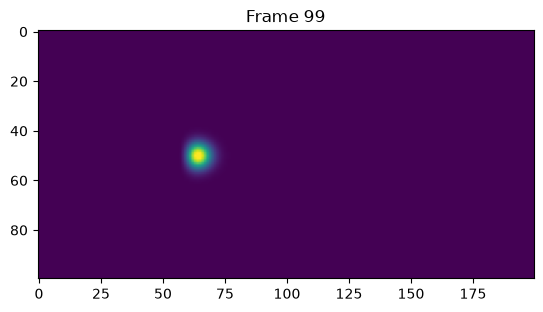

In [9]:
# Generación de la animación 
data = matrix_full_steps.copy()

fig, ax = plt.subplots()
im = ax.imshow(data[0], cmap='viridis', animated=True)#, vmin=0, vmax=1)
title = ax.set_title("Frame 0")

def update(frame_idx):
    im.set_array(data[frame_idx])
    title.set_text(f"Frame {frame_idx}")
    return [im, title]

ani = animation.FuncAnimation(
    fig, update, frames=steps, interval=200, blit=True
)

HTML(ani.to_jshtml())  # for Jupyter notebooks